# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [ ]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [3]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()

duplicate_count = df.duplicated().sum()
print("Exact duplicate rows:", duplicate_count)
print(df.shape)
print("Original column types:")
df.info()
print(df.isnull().sum())
print(df.describe())
print(df['MSRP'].value_counts().head())
print(df.sort_values('MSRP', ascending=False).head())
print(df.sort_values('highway MPG', ascending=False).head(15))
for column in ['Engine Fuel Type', 'Transmission Type', 'Driven_Wheels',
               'Number of Doors', 'Vehicle Size', 'Vehicle Style']:
    print(column)
    print(df[column].value_counts(dropna=False))
print("HP missing, by fuel type:")
print(df[df['Engine HP'].isnull()]['Engine Fuel Type'].value_counts(dropna=False))
print("Prices at the apparent floor, by year:")
print(df[df['MSRP'] == 2000]['Year'].value_counts().sort_index())
print("Distinct popularity values per make:")
print(df.groupby('Make')['Popularity'].nunique())
print("Rows per make/model/year:")
print(df.groupby(['Make', 'Model', 'Year'])['MSRP'].count().sort_values(ascending=False).head(10))
text_columns = ['Make', 'Model', 'Engine Fuel Type', 'Transmission Type',
                'Driven_Wheels', 'Vehicle Size', 'Vehicle Style']
print("Text values with leading or trailing whitespace:")
for column in text_columns:
    values = df[column].dropna()
    print(column, (values != values.str.strip()).sum())
print("Category labels (original count vs. case-insensitive count):")
for column in ['Make', 'Engine Fuel Type', 'Transmission Type',
               'Driven_Wheels', 'Vehicle Size', 'Vehicle Style']:
    values = df[column].dropna()
    print(column, values.nunique(), values.str.lower().nunique())

Exact duplicate rows: 720
(11914, 15)
Original column types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Vehicle Size       11914 non-null  object 
 10  Vehicle Style      11914 non-null  object 
 11  highway MPG        11914 non-null  int64  
 12  city mpg           11914 non-null  int64  
 13  Popularity         11914 non-null  int64  
 14  MSRP               11914 non-null  int64  
dtypes: float6

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Duplicate rows | `.duplicated().sum()` | 720 | Removed the extra copies | The same car shouldn't be counted more than once. |
| 2 | Suspicious $2,000 prices | Checked common MSRP values and model years | 747 | Flagged them and changed MSRP to NaN | So many older cars have this exact price that I don't trust it, but I kept the rest of each row. |
| 3 | Missing specifications | `.isnull().sum()` | 102 | Left the missing values as they were | The other information in those rows can still be useful. |
| 4 | Highway MPG of 354 | Checked the highest highway MPG values | 1 | Flagged it and changed highway MPG to NaN | The value for the 2017 Audi A6 doesn't look realistic. |
| 5 | Electric efficiency values | Checked fuel types | 66 | Kept the original values separately and left them out of MPG comparisons | Electric efficiency figures aren't directly comparable to gas MPG. |
| 6 | Unknown transmissions | `.value_counts()` | 12 | Changed `UNKNOWN` to NaN | It doesn't tell us what transmission the car has. |

In [4]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names
clean = clean.drop_duplicates().copy()

missing_counts = clean.isnull().sum()
missing_rows = clean.isnull().any(axis=1).sum()
price_floor = clean['msrp'] == 2000
bad_highway = clean['highway_mpg'] == 354
electric = clean['engine_fuel_type'] == 'electric'
unknown_transmission = clean['transmission_type'] == 'UNKNOWN'
print("Missing specification counts:", missing_counts)
print("Rows with missing specifications:", missing_rows)
print("Price floor:", price_floor.sum())
print("Suspicious highway MPG:", bad_highway.sum())
print("Electric efficiency rows:", electric.sum())
print("Unknown transmission:", unknown_transmission.sum())

clean['price_floor_flag'] = np.where(price_floor, True, False)
clean['electric_efficiency_flag'] = np.where(electric, True, False)
clean['highway_error_flag'] = np.where(bad_highway, True, False)
clean.loc[price_floor, 'msrp'] = np.nan
clean.loc[bad_highway, 'highway_mpg'] = np.nan
clean['electric_highway_reported'] = np.where(electric, clean['highway_mpg'], np.nan)
clean['electric_city_reported'] = np.where(electric, clean['city_mpg'], np.nan)
clean.loc[electric, 'highway_mpg'] = np.nan
clean.loc[electric, 'city_mpg'] = np.nan
clean.loc[unknown_transmission, 'transmission_type'] = np.nan

model_counts = clean.groupby(['make', 'model', 'year'])['year'].count()
repeated_model_rows = model_counts[model_counts > 1].sum()
print("Rows in repeated make/model/year groups:", repeated_model_rows)
print("Remaining exact duplicate records:", clean.duplicated().sum())
print("Years outside the documented 1990–2017 range:",
      ((clean['year'] < 1990) | (clean['year'] > 2017)).sum())
print("Remaining non-positive prices:", (clean['msrp'] <= 0).sum())
print("Remaining non-positive highway or city MPG:",
      (clean['highway_mpg'] <= 0).sum(), (clean['city_mpg'] <= 0).sum())
print("Door counts outside 2, 3, or 4:",
      (clean['number_of_doors'].notna() &
       ~clean['number_of_doors'].isin([2, 3, 4])).sum())
print("Non-electric cars reporting zero cylinders:",
      ((clean['engine_cylinders'] == 0) &
       (clean['engine_fuel_type'] != 'electric')).sum())

Missing specification counts: make                  0
model                 0
year                  0
engine_fuel_type      3
engine_hp            69
engine_cylinders     30
transmission_type     0
driven_wheels         0
number_of_doors       6
vehicle_size          0
vehicle_style         0
highway_mpg           0
city_mpg              0
popularity            0
msrp                  0
dtype: int64
Rows with missing specifications: 102
Price floor: 747
Suspicious highway MPG: 1
Electric efficiency rows: 66
Unknown transmission: 12
Rows in repeated make/model/year groups: 10669
Remaining exact duplicate records: 0
Years outside the documented 1990–2017 range: 0
Remaining non-positive prices: 0
Remaining non-positive highway or city MPG: 0 0
Door counts outside 2, 3, or 4: 0
Non-electric cars reporting zero cylinders: 0


In [5]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.
print("Final column types:")
clean.info()
print("Final numeric summary:")
print(clean.describe())
print("Final exact duplicate rows:", clean.duplicated().sum())
print("Remaining UNKNOWN transmissions:",
      (clean['transmission_type'] == 'UNKNOWN').sum())
print("Text columns with remaining leading or trailing whitespace:")
for column in text_columns:
    values = clean[column.lower().replace(' ', '_')].dropna()
    print(column, (values != values.str.strip()).sum())

(11194, 20)
engine_fuel_type                 3
engine_hp                       69
engine_cylinders                30
transmission_type               12
number_of_doors                  6
highway_mpg                     67
city_mpg                        66
msrp                           747
electric_highway_reported    11128
electric_city_reported       11128
dtype: int64
Final column types:
<class 'pandas.core.frame.DataFrame'>
Index: 11194 entries, 0 to 11913
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   make                       11194 non-null  object 
 1   model                      11194 non-null  object 
 2   year                       11194 non-null  int64  
 3   engine_fuel_type           11191 non-null  object 
 4   engine_hp                  11125 non-null  float64
 5   engine_cylinders           11164 non-null  float64
 6   transmission_type          11182 non-null  objec

               year     engine_hp  engine_cylinders  number_of_doors  \
count  11194.000000  11125.000000      11164.000000     11188.000000   
mean    2010.715026    253.390562          5.665801         3.454058   
std        7.226875    110.170627          1.797210         0.872972   
min     1990.000000     55.000000          0.000000         2.000000   
25%     2007.000000    172.000000          4.000000         2.000000   
50%     2015.000000    239.000000          6.000000         4.000000   
75%     2016.000000    303.000000          6.000000         4.000000   
max     2017.000000   1001.000000         16.000000         4.000000   

        highway_mpg      city_mpg    popularity          msrp  \
count  11127.000000  11128.000000  11194.000000  1.044700e+04   
mean      26.147928     19.180715   1557.964445  4.478867e+04   
std        6.260440      5.598289   1445.449268  6.274367e+04   
min       12.000000      7.000000      2.000000  2.002000e+03   
25%       22.000000     16

Engine Fuel Type 0
Transmission Type 0
Driven_Wheels 0
Vehicle Size 0
Vehicle Style 0


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Valid prices: 10,447
Mean: $44,788.67; median: $31,870.00


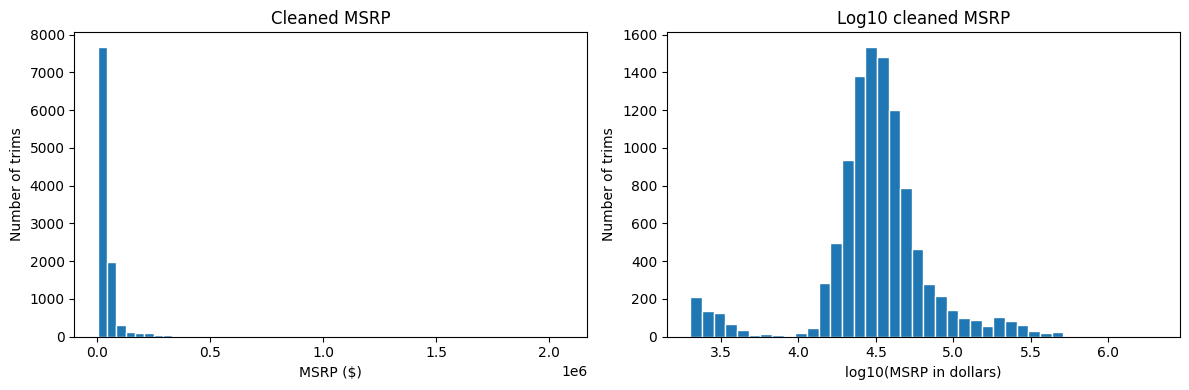

Above mean: 24.45%


In [6]:
# a) mean and median
prices = clean['msrp'].dropna()
mean_price = prices.mean()
median_price = prices.median()
print(f"Valid prices: {len(prices):,}")
print(f"Mean: ${mean_price:,.2f}; median: ${median_price:,.2f}")

# b) two histograms side by side (plt.subplots(1, 2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prices, bins=50, edgecolor='white')
axes[0].set(title='Cleaned MSRP', xlabel='MSRP ($)', ylabel='Number of trims')
axes[1].hist(np.log10(prices), bins=40, edgecolor='white')
axes[1].set(title='Log10 cleaned MSRP', xlabel='log10(MSRP in dollars)', ylabel='Number of trims')
plt.tight_layout()
plt.show()

# c) share of cars above the mean
above_mean_percent = len(prices[prices > mean_price]) / len(prices) * 100
print(f"Above mean: {above_mean_percent:.2f}%")

**Answer:** The mean price is $44,788.67, which is higher than the $31,870 median because a few expensive cars bring the average up. The price histogram is skewed to the right, while the log-price histogram looks more balanced, and 24.45% of cars cost more than the mean. I'd put the median on the homepage because it's closer to what a typical listed car costs.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [7]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
cars_2017 = clean[clean['year'] == 2017].copy()
size_mpg = cars_2017.groupby('vehicle_size')['highway_mpg'].agg(['count', 'mean', 'std'])
print(size_mpg)

# b) z = (value - class mean) / class std
civic_z = (42 - size_mpg.loc['Compact', 'mean']) / size_mpg.loc['Compact', 'std']
volvo_z = (34 - size_mpg.loc['Large', 'mean']) / size_mpg.loc['Large', 'std']
print(f"Civic z-score: {civic_z:.3f}; Volvo z-score: {volvo_z:.3f}")

              count       mean       std
vehicle_size                            
Compact         509  30.880157  6.045381
Large           468  22.991453  3.491184
Midsize         638  29.410658  5.452292
Civic z-score: 1.839; Volvo z-score: 3.153


**Answer:** The Volvo S90 stands out more for its size at 3.15 standard deviations above the large-car average, compared with 1.84 for the Civic in the compact class.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

Eligible makes:
make
Acura         36
Buick         39
Chrysler      24
FIAT          19
Genesis        3
Hyundai       42
Infiniti      28
Kia           43
Land Rover    11
Lexus         34
Lincoln       46
Lotus          1
Maserati      10
Mazda         24
Mitsubishi    29
Porsche       25
Subaru        46
Volvo         23
Name: msrp, dtype: int64


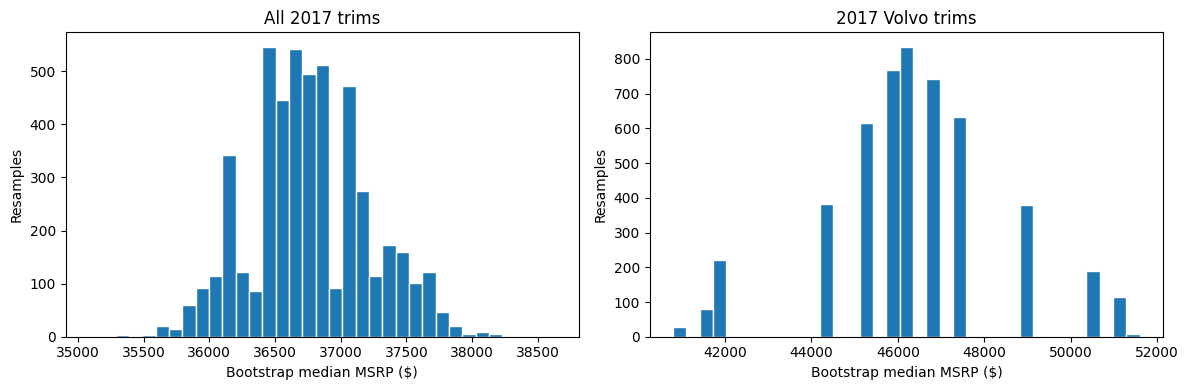

All 2017: n=1624, median=$36,737.50, CI=[35940.     37682.5625]
Volvo: n=23, median=$46,350.00, CI=[41750. 50450.]
Interval widths: 1742.5625 8700.0


In [8]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    medians = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        medians.append(np.median(sample))
    return np.array(medians)

# a, b)
prices_2017 = cars_2017['msrp'].dropna()
median_2017 = prices_2017.median()
bootstrap_all = bootstrap_median(prices_2017)
interval_all = np.percentile(bootstrap_all, [2.5, 97.5])

# c)
make_counts = cars_2017.groupby('make')['msrp'].count()
print("Eligible makes:")
print(make_counts[(make_counts > 0) & (make_counts < 50)])
chosen_make = 'Volvo'
make_prices = cars_2017[cars_2017['make'] == chosen_make]['msrp'].dropna()
bootstrap_make = bootstrap_median(make_prices)
interval_make = np.percentile(bootstrap_make, [2.5, 97.5])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(bootstrap_all, bins=35, edgecolor='white')
axes[0].set(title='All 2017 trims', xlabel='Bootstrap median MSRP ($)', ylabel='Resamples')
axes[1].hist(bootstrap_make, bins=35, edgecolor='white')
axes[1].set(title='2017 Volvo trims', xlabel='Bootstrap median MSRP ($)', ylabel='Resamples')
plt.tight_layout()
plt.show()
print(f"All 2017: n={len(prices_2017)}, median=${median_2017:,.2f}, CI={interval_all}")
print(f"Volvo: n={len(make_prices)}, median=${make_prices.median():,.2f}, CI={interval_make}")
print("Interval widths:", interval_all[1] - interval_all[0], interval_make[1] - interval_make[0])

**Answer:** Volvo's interval ($41,750 to $50,450) is wider because it only has 23 listings, compared with 1,624 for all 2017 cars. For the overall market, the typical listed 2017 car costs about $36,738, with a 95% confidence interval from roughly $35,940 to $37,683.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

count    509.000000
mean      30.880157
std        6.045381
min       19.000000
25%       26.000000
50%       30.000000
75%       35.000000
max       53.000000
Name: highway_mpg, dtype: float64


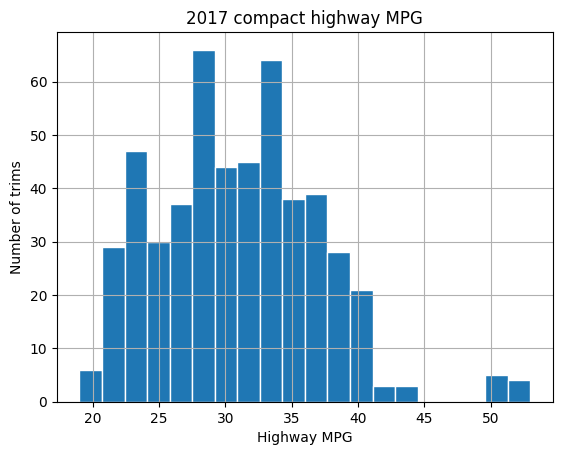

Trim counts by make/model:
make           model             
Acura          ILX                    6
               NSX                    1
Audi           A3                    12
               Q3                     6
               R8                     2
               S3                     2
               TT                     2
               TTS                    1
BMW            2 Series               8
               M2                     1
               X1                     2
Buick          Encore                10
Cadillac       ATS Coupe              7
               ATS-V                  2
Chevrolet      City Express           2
               Corvette              24
               Cruze                  3
               Equinox                7
               Sonic                 10
               Spark                  6
               Trax                   6
Dodge          Viper                  4
FIAT           124 Spider             3
               500 

In [9]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact_2017 = cars_2017[cars_2017['vehicle_size'] == 'Compact'].copy()
compact_2017 = compact_2017.dropna(subset=['highway_mpg'])
compact_mpg = compact_2017['highway_mpg']
print(compact_mpg.describe())
compact_mpg.hist(bins=20, edgecolor='white')
plt.title('2017 compact highway MPG')
plt.xlabel('Highway MPG')
plt.ylabel('Number of trims')
plt.show()

# c) one-sample t-test vs 30
compact_test = stats.ttest_1samp(compact_mpg, 30, alternative='greater')

# d) rows per make+model, then one row per model and retest
rows_per_model = compact_2017.groupby(['make', 'model'])['highway_mpg'].count()
print("Trim counts by make/model:")
print(rows_per_model.to_string())
model_mpg = compact_2017.groupby(['make', 'model'])['highway_mpg'].mean()
model_test = stats.ttest_1samp(model_mpg, 30, alternative='greater')
print(f"Trim sample: n={len(compact_mpg)}, mean={compact_mpg.mean():.3f}, t={compact_test.statistic:.3f}, p={compact_test.pvalue:.6g}")
print(f"Model sample: n={len(model_mpg)}, mean={model_mpg.mean():.3f}, t={model_test.statistic:.3f}, p={model_test.pvalue:.6g}")

**Answer:** I used a one-sided test because we want to know whether the average is above 30 MPG (H₀: μ ≤ 30, Hₐ: μ > 30). The 509 compact trims average 30.88 MPG, and although the histogram has some higher-MPG values, the sample is large enough for a t-test, which gives p = 0.00055. After averaging the trims into 85 make/model groups, the mean is 31.69 MPG and p = 0.00585, so the claim still holds and I'd trust this version more because repeated trims have less influence.

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [10]:
# a) compare median MSRP by transmission type
transmissions = clean[clean['transmission_type'].isin(['AUTOMATIC', 'MANUAL'])].copy()
transmission_prices = transmissions.groupby('transmission_type')['msrp'].agg(['count', 'median'])
print("All years, valid prices:")
print(transmission_prices)

# b) compare year by transmission type
print("Year distributions (including rows without usable prices):")
print(transmissions.groupby('transmission_type')['year'].describe())
print("Years among rows with usable prices:")
print(transmissions.dropna(subset=['msrp']).groupby('transmission_type')['year'].describe())

# c) compare 2015-2017 medians overall and within each vehicle_size
recent = transmissions[(transmissions['year'] >= 2015) & (transmissions['year'] <= 2017)].copy()
recent_prices = recent.groupby('transmission_type')['msrp'].agg(['count', 'median'])
size_prices = recent.groupby(['vehicle_size', 'transmission_type'])['msrp'].agg(['count', 'median'])
print("2015-2017:")
print(recent_prices)
print("2015-2017 by size:")
print(size_prices)
recent_compact = recent[recent['vehicle_size'] == 'Compact']
auto = recent_compact[recent_compact['transmission_type'] == 'AUTOMATIC']['msrp'].dropna()
manual = recent_compact[recent_compact['transmission_type'] == 'MANUAL']['msrp'].dropna()
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
u_test = stats.mannwhitneyu(auto, manual, alternative='two-sided')
print(f"Compact automatic median=${auto.median():,.2f}, manual median=${manual.median():,.2f}")
print(f"U={u_test.statistic:,.1f}, p={u_test.pvalue:.6g}")

All years, valid prices:
                   count   median
transmission_type                
AUTOMATIC           7635  33620.0
MANUAL              2184  21875.0
Year distributions (including rows without usable prices):
                    count         mean       std     min     25%     50%  \
transmission_type                                                          
AUTOMATIC          7928.0  2011.843340  6.228801  1990.0  2009.0  2015.0   
MANUAL             2633.0  2006.475503  8.788607  1990.0  1998.0  2008.0   

                      75%     max  
transmission_type                  
AUTOMATIC          2016.0  2017.0  
MANUAL             2015.0  2017.0  
Years among rows with usable prices:
                    count         mean       std     min     25%     50%  \
transmission_type                                                          
AUTOMATIC          7635.0  2012.533857  5.211005  1990.0  2010.0  2015.0   
MANUAL             2184.0  2009.136905  7.095968  1990.0  2003.0  

**Answer:** Across all years, manual cars have a median price of $21,875 compared with $33,620 for automatics, but manuals also tend to be older. Among 2015–2017 compact cars, the difference is only $135 ($25,860 for manuals and $25,995 for automatics), and the p-value of 0.205 doesn't give strong evidence of a price difference. I'd tell the sales rep that manuals look cheaper overall, but we shouldn't recommend them as the cheaper option without comparing similar cars.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [11]:
# a) Welch t-test, 4-door vs 2-door
valid_mpg = clean.dropna(subset=['highway_mpg'])
four_door = valid_mpg[valid_mpg['number_of_doors'] == 4]['highway_mpg']
two_door = valid_mpg[valid_mpg['number_of_doors'] == 2]['highway_mpg']
welch_test = stats.ttest_ind(four_door, two_door, equal_var=False)
mpg_difference = four_door.mean() - two_door.mean()

# b) yearly gas cost = miles * price_per_gallon / mpg
miles, gas_price = 12000, 3.50
four_cost = miles * gas_price / four_door.mean()
two_cost = miles * gas_price / two_door.mean()
annual_savings = two_cost - four_cost
print(f"4 doors: n={len(four_door)}, mean MPG={four_door.mean():.3f}, cost=${four_cost:,.2f}")
print(f"2 doors: n={len(two_door)}, mean MPG={two_door.mean():.3f}, cost=${two_cost:,.2f}")
print(f"MPG difference={mpg_difference:.3f}; p={welch_test.pvalue:.6g}; annual savings=${annual_savings:,.2f}")

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    sample_four = rng.choice(four_door, 30, replace=False)
    sample_two = rng.choice(two_door, 30, replace=False)
    result = stats.ttest_ind(sample_four, sample_two, equal_var=False)
    if result.pvalue < 0.05:
        hits += 1
significant_percent = hits / n_sims * 100
print(f"Significant experiments: {hits}/{n_sims} ({significant_percent:.1f}%)")

4 doors: n=7897, mean MPG=26.805, cost=$1,566.89
2 doors: n=2873, mean MPG=25.257, cost=$1,662.94
MPG difference=1.548; p=2.10565e-32; annual savings=$96.05


Significant experiments: 158/1000 (15.8%)


**Answer:** Four-door cars average 1.55 more highway MPG than two-door cars (p ≈ 2.1 × 10⁻³²), which works out to about $96 a year in estimated gas savings. Only 15.8% of the smaller tests were significant. I wouldn't call four-door cars significantly more fuel-efficient in an ad, but I'd say that they had slightly better highway MPG on average in these listings.

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** In the 2015–2017 listings, manual cars have a median price of $26,905 compared with $37,065 for automatics. But for compact cars from those same years, the prices are almost the same at $25,860 for manuals and $25,995 for automatics. I'd use the $31,870 median price on the homepage instead of the $44,789 mean because expensive cars bring the average up. One limitation is that these are older car listings, not actual sales, so they might not reflect what people pay today.

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [12]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [13]:
# S2